In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#importing all required python libraries
import pandas as pd
import shap #loading SHAP tool for XAI based explanation
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn import metrics 
import seaborn as sns
import matplotlib.pyplot as plt #use to visualize dataset values
import os

In [3]:
#loading and displaying hospital stay icu dataset
dataset = pd.read_csv("Dataset/LengthOfStay.csv", nrows=2000)
dataset

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,0
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,1
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,0
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,0
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,11/18/2012,2,M,1,0,1,0,0,0,...,61.560195,30.0,0.941336,27.621422,60,5.3,1,11/26/2012,E,1
1996,1997,2/21/2012,0,M,1,0,0,0,0,0,...,165.808034,19.0,1.377759,29.148367,70,6.5,1,2/24/2012,E,0
1997,1998,1/19/2012,1,F,0,0,0,0,0,0,...,115.590613,12.0,0.930608,31.128404,85,6.5,3,1/21/2012,A,0
1998,1999,3/6/2012,4,F,0,0,0,0,0,0,...,149.005998,12.0,1.055497,31.732607,89,6.5,6,3/14/2012,B,1


In [4]:
#describing dataset to know distribution of values ranges in each column
dataset.describe()

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,0.044000,0.025000,0.101500,0.037500,0.064000,0.222000,0.048500,0.04800,0.007000,...,10.070517,137.908681,141.683766,14.302833,1.097572,29.839242,73.30150,6.476879,2.176500,0.365500
std,577.494589,0.205146,0.156164,0.302065,0.190031,0.244814,0.415695,0.214874,0.21382,0.083394,...,4.520339,2.960858,28.956846,10.925403,0.199526,1.948999,11.34213,0.556073,2.108452,0.481691
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.200000,127.900753,33.110016,3.000000,0.402261,22.643540,27.00000,3.100000,0.000000,0.000000
25%,500.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,7.500000,135.955837,122.479489,11.000000,0.965401,28.492700,66.00000,6.500000,1.000000,0.000000
50%,1000.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,9.400000,137.864045,141.695184,12.000000,1.098667,29.927772,73.00000,6.500000,1.000000,0.000000
75%,1500.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,11.500000,139.856264,161.118797,14.000000,1.234321,31.192184,81.00000,6.500000,3.000000,1.000000
max,2000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,...,71.500000,148.878278,230.070563,252.500000,1.796256,35.482148,109.00000,9.200000,10.000000,1.000000


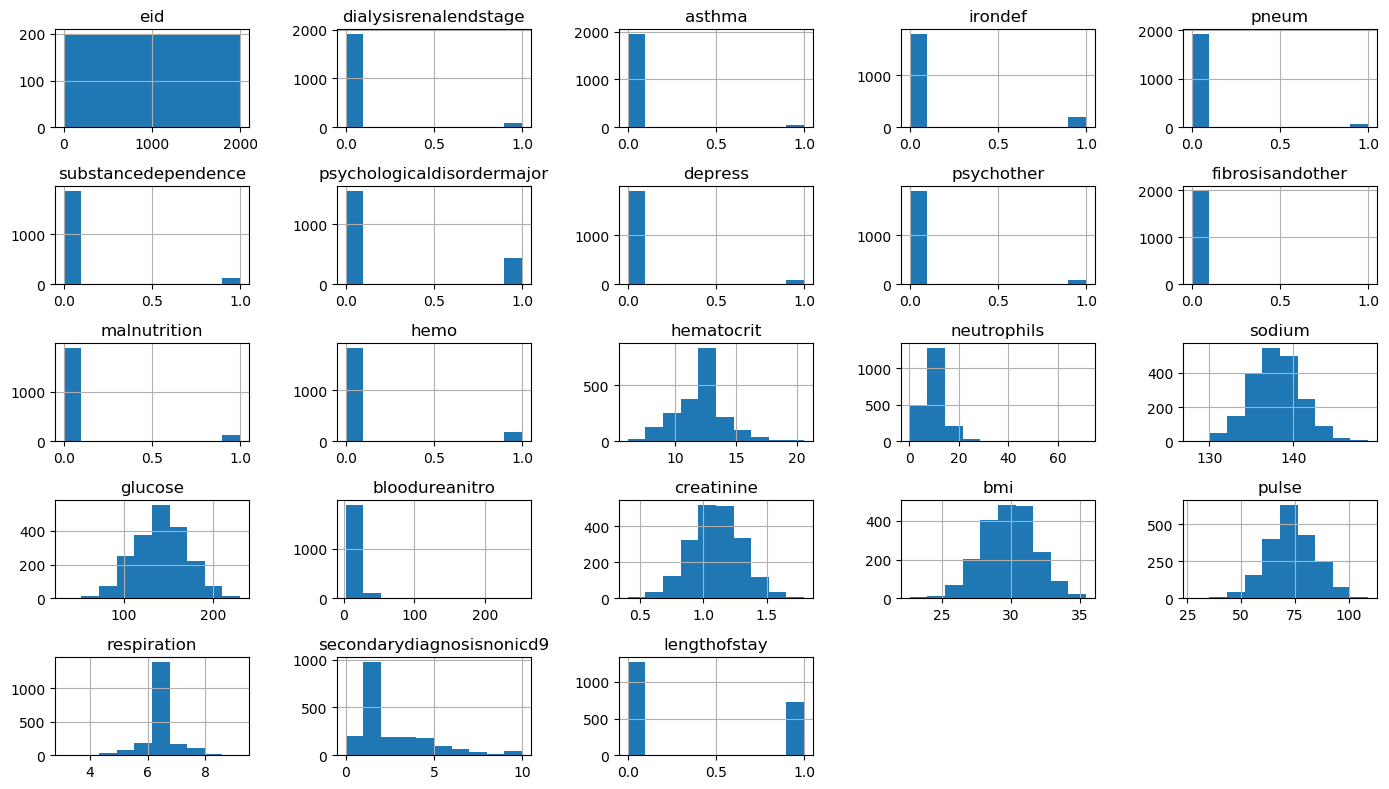

In [5]:
#visualizing distribution of numerical data
dataset.hist(figsize=(14, 8))
plt.title("Representation of Dataset Attributes")
plt.tight_layout()
plt.show()

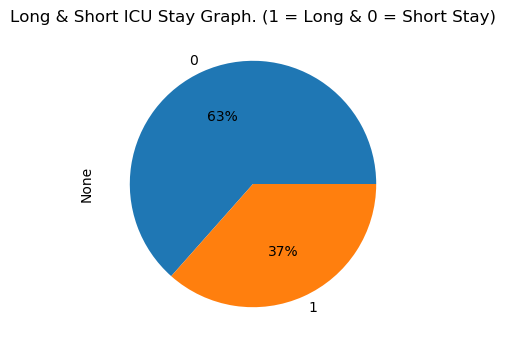

In [6]:
#describe and plotting graph of Long and Short ICU stay 
dataset.groupby("lengthofstay").size().plot.pie(autopct='%.0f%%', figsize=(4, 4))
plt.title("Long & Short ICU Stay Graph. (1 = Long & 0 = Short Stay)")
plt.show()

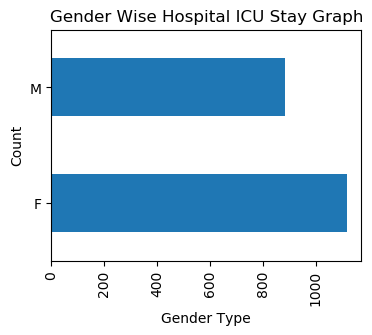

In [7]:
#finding plotting graph of gender wise hospital long and short stay
dataset['gender'].value_counts().plot(kind='barh', figsize=(4, 3))
plt.title("Gender Wise Hospital ICU Stay Graph")
plt.xlabel("Gender Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [8]:
#dataset pre-processing like converting non-numeric data to numeric data using label encoder class
dataset['vdate'] = pd.to_datetime(dataset['vdate'])
dataset['year'] = dataset['vdate'].dt.year
dataset['month'] = dataset['vdate'].dt.month
dataset['day'] = dataset['vdate'].dt.day
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for i in range(len(types)):
    name = types[i]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[i]] = pd.Series(le.fit_transform(dataset[columns[i]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[i], le])
Y = dataset['lengthofstay'].ravel()
dataset.drop(['eid', 'vdate','lengthofstay'], axis = 1,inplace=True)#drop ir-relevant columns
print("Cleaned & Processed Dataset")
dataset

Cleaned & Processed Dataset


,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,...,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,year,month,day
0,0,0,0,0,0,0,0,0,0,0,...,1.390722,30.432418,96,6.5,4,342,1,2012,8,29
1,5,0,0,0,0,0,0,0,0,0,...,0.943164,28.460516,61,6.5,1,261,0,2012,5,26
2,1,0,0,0,0,0,0,0,0,0,...,1.065750,28.843812,64,6.5,2,359,1,2012,9,22
3,0,0,0,0,0,0,0,0,0,0,...,0.906862,27.959007,76,6.5,1,312,0,2012,8,9
4,0,0,0,0,0,1,0,1,0,0,...,1.242854,30.258927,67,5.6,2,114,4,2012,12,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2,1,1,0,1,0,0,0,1,1,...,0.941336,27.621422,60,5.3,1,86,4,2012,11,18
1996,0,1,1,0,0,0,0,0,1,0,...,1.377759,29.148367,70,6.5,1,145,4,2012,2,21
1997,1,0,0,0,0,0,0,0,0,0,...,0.930608,31.128404,85,6.5,3,14,0,2012,1,19
1998,4,0,0,0,0,0,0,0,0,0,...,1.055497,31.732607,89,6.5,6,163,1,2012,3,6


In [9]:
#applying imputation to replace missing values with mean
dataset = dataset.fillna(dataset.mean())
columns = dataset.columns
X = dataset.values
#normalizing training features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
print("Normalized Training Features = "+str(X))

Normalized Training Features = [[0.         0.         0.         ... 0.         0.63636364 0.93333333]
 [1.         0.         0.         ... 0.         0.36363636 0.83333333]
 [0.2        0.         0.         ... 0.         0.72727273 0.7       ]
 ...
 [0.2        0.         0.         ... 0.         0.         0.6       ]
 [0.8        0.         0.         ... 0.         0.18181818 0.16666667]
 [0.4        1.         0.         ... 0.         1.         0.46666667]]


In [10]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Train & Test Split Details")
print("80% records used to train algorithms : "+str(X_train.shape[0]))
print("20% records used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Dataset Train & Test Split Details
80% records used to train algorithms : 1600
20% records used to test algorithms : 400


In [11]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []
labels = ['Short Stay', 'Long Stay']

In [12]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()  

Logistic Regression Accuracy  : 90.0
Logistic Regression Precision : 89.86676016830295
Logistic Regression Recall    : 87.73647527381347
Logistic Regression FSCORE    : 88.64894009478135


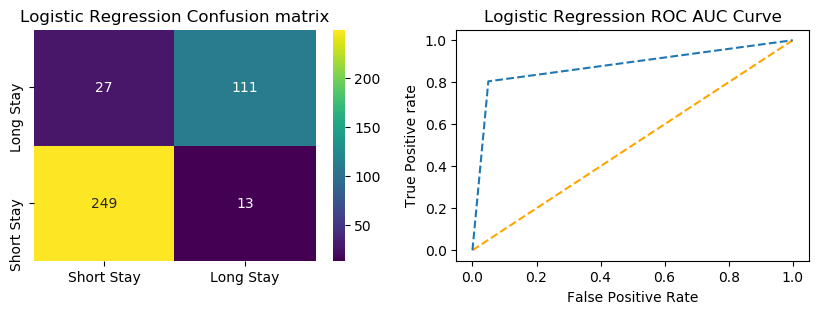

In [13]:
#training logistic regression algorithm using tuning grid search parameters
#defining tuning parameters list
hyperParameters = {'solver': ['liblinear', 'newton-cg'], 'C': [0.001, 0.01, 1]}
lr_cls =  LogisticRegression()
lr_cls1 = GridSearchCV(lr_cls, hyperParameters, scoring='accuracy')
#training logistic regression algorithm on training features
lr_cls.fit(X_train, y_train)  
#performing prediction on test data
predict = lr_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Logistic Regression", y_test, predict)

Multilayer Perceptron Accuracy  : 91.5
Multilayer Perceptron Precision : 92.02380952380953
Multilayer Perceptron Recall    : 89.05299258767563
Multilayer Perceptron FSCORE    : 90.27432134786464


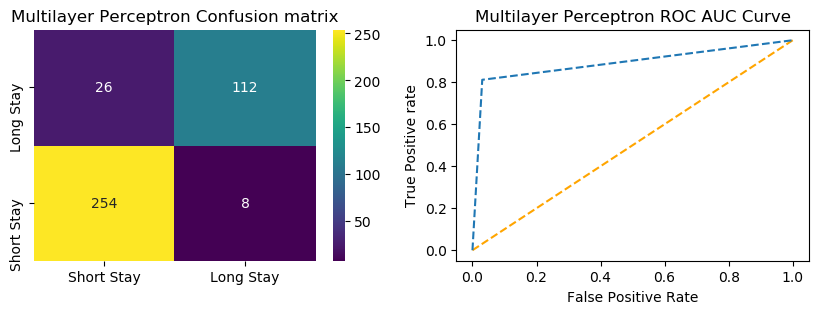

In [14]:
#training MLP algorithm using tuning grid search parameters
#defining tuning parameters list
hyperParameters = {'learning_rate_init': [0.01], 'activation': ['logistic', 'tanh'], 'hidden_layer_sizes': [10, 50]}
mlp_cls =  MLPClassifier(max_iter=1000, hidden_layer_sizes=10)
mlp_cls1 = GridSearchCV(mlp_cls, hyperParameters, scoring='accuracy')
#training MLP algorithm on training features
mlp_cls.fit(X_train, y_train)  
#performing prediction on test data
predict = mlp_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Multilayer Perceptron", y_test, predict)

Random Forest Accuracy  : 92.75
Random Forest Precision : 93.87363715985624
Random Forest Recall    : 90.17867020688128
Random Forest FSCORE    : 91.65317503148047


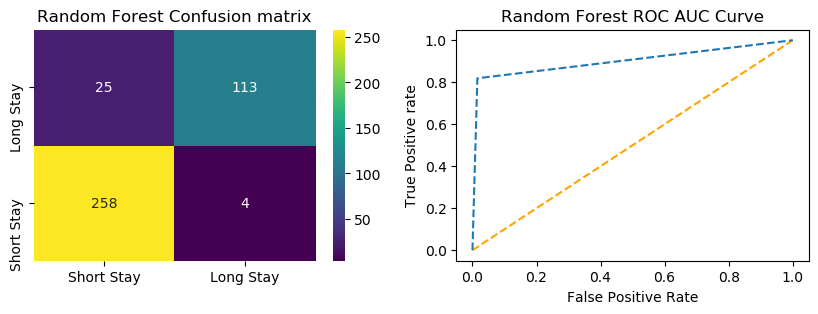

In [15]:
#training Random Forest algorithm using tuning grid search parameters
#defining tuning parameters list
hyperParameters = {'n_estimators': [5, 50, 250], 'max_depth': [4, 8], 'max_features': ['sqrt', 'log2']}
rf_cls =  RandomForestClassifier(n_estimators=2)
rf_cls1 = GridSearchCV(rf_cls, hyperParameters, scoring='accuracy')
#training Random Forest algorithm on training features
rf_cls.fit(X_train, y_train)  
#performing prediction on test data
predict = rf_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Random Forest", y_test, predict)

Gradient Boosting Accuracy  : 95.0
Gradient Boosting Precision : 96.45390070921987
Gradient Boosting Recall    : 92.7536231884058
Gradient Boosting FSCORE    : 94.25551470588235


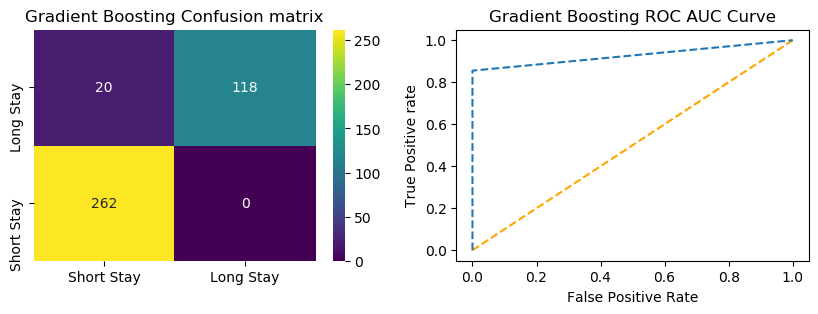

In [16]:
#training Gradient Boosting algorithm using tuning grid search parameters
#defining tuning parameters list
hyperParameters = {'n_estimators': [5, 50, 500], 'max_depth': [1, 5, 9], 'learning_rate': [0.01]}
gb_cls =  GradientBoostingClassifier(n_estimators=50)
gb_cls1 = GridSearchCV(gb_cls, hyperParameters, scoring='accuracy')
#training Gradient Boosting algorithm on training features
gb_cls.fit(X_train, y_train)  
#performing prediction on test data
predict = gb_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Gradient Boosting", y_test, predict)

XGBoost Accuracy  : 97.5
XGBoost Precision : 98.16176470588236
XGBoost Recall    : 96.3768115942029
XGBoost FSCORE    : 97.18397116386471


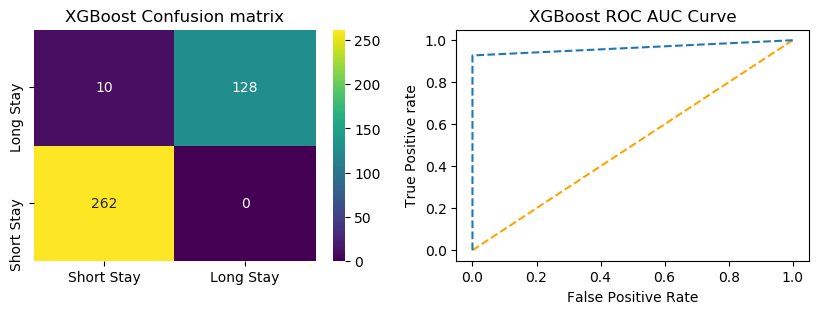

In [17]:
#training XGBoost algorithm using tuning grid search parameters
#defining tuning parameters list
hyperParameters = {'n_estimators': [5, 100, 250], 'max_depth': [1, 3, 5], 'learning_rate': [0.01, 0.1, 1]}
xg_cls =  XGBClassifier(n_estimators=10)
xg_cls1 = GridSearchCV(xg_cls, hyperParameters, scoring='accuracy')
#training XGBoost algorithm on training features
xg_cls.fit(X_train, y_train)  
#performing prediction on test data
predict = xg_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("XGBoost", y_test, predict)

Learning rate set to 0.47851
0:	learn: 0.3551454	total: 144ms	remaining: 2.74s
1:	learn: 0.2883808	total: 146ms	remaining: 1.32s
2:	learn: 0.2538183	total: 148ms	remaining: 840ms
3:	learn: 0.2307774	total: 150ms	remaining: 601ms
4:	learn: 0.2068138	total: 152ms	remaining: 457ms
5:	learn: 0.1879556	total: 154ms	remaining: 360ms
6:	learn: 0.1727154	total: 156ms	remaining: 290ms
7:	learn: 0.1629357	total: 158ms	remaining: 237ms
8:	learn: 0.1514278	total: 160ms	remaining: 196ms
9:	learn: 0.1408223	total: 162ms	remaining: 162ms
10:	learn: 0.1340799	total: 164ms	remaining: 134ms
11:	learn: 0.1277976	total: 166ms	remaining: 111ms
12:	learn: 0.1210920	total: 168ms	remaining: 90.3ms
13:	learn: 0.1132709	total: 169ms	remaining: 72.6ms
14:	learn: 0.1059651	total: 171ms	remaining: 57ms
15:	learn: 0.0988512	total: 172ms	remaining: 43.1ms
16:	learn: 0.0941587	total: 174ms	remaining: 30.6ms
17:	learn: 0.0881663	total: 175ms	remaining: 19.4ms
18:	learn: 0.0847052	total: 176ms	remaining: 9.27ms
19:	lea

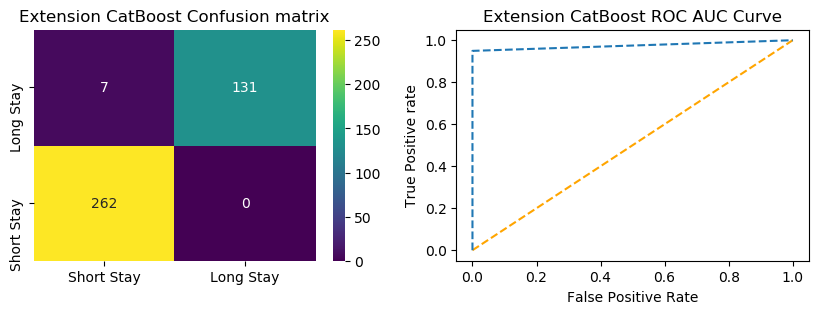

In [18]:
#training CatBoost algorithm on tuning parameters
extension_model = CatBoostClassifier(iterations = 20)
#training CatBoost algorithm on training features
extension_model.fit(X_train, y_train)
#perform prediction on test data
predict = extension_model.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Extension CatBoost", y_test, predict)

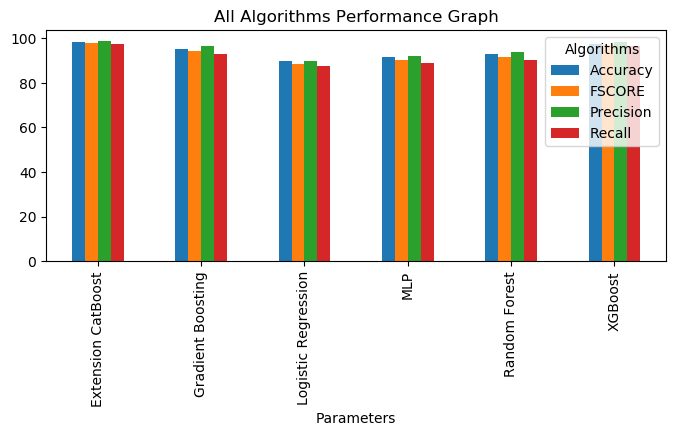

In [19]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['Logistic Regression','Accuracy',accuracy[0]],['Logistic Regression','Precision',precision[0]],['Logistic Regression','Recall',recall[0]],['Logistic Regression','FSCORE',fscore[0]],
                   ['MLP','Accuracy',accuracy[1]],['MLP','Precision',precision[1]],['MLP','Recall',recall[1]],['MLP','FSCORE',fscore[1]],
                   ['Random Forest','Accuracy',accuracy[2]],['Random Forest','Precision',precision[2]],['Random Forest','Recall',recall[2]],['Random Forest','FSCORE',fscore[2]],
                   ['Gradient Boosting','Accuracy',accuracy[3]],['Gradient Boosting','Precision',precision[3]],['Gradient Boosting','Recall',recall[3]],['Gradient Boosting','FSCORE',fscore[3]],
                   ['XGBoost','Accuracy',accuracy[4]],['XGBoost','Precision',precision[4]],['XGBoost','Recall',recall[4]],['XGBoost','FSCORE',fscore[4]],
                   ['Extension CatBoost','Accuracy',accuracy[5]],['Extension CatBoost','Precision',precision[5]],['Extension CatBoost','Recall',recall[5]],['Extension CatBoost','FSCORE',fscore[5]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [20]:
#display all algorithm performnace
algorithms = ['Logistic Regression', 'MLP', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'Extension CatBoost']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Logistic Regression,90.00,89.866760,87.736475,88.648940
1,MLP,91.50,92.023810,89.052993,90.274321
2,Random Forest,92.75,93.873637,90.178670,91.653175
3,Gradient Boosting,95.00,96.453901,92.753623,94.255515
4,XGBoost,97.50,98.161765,96.376812,97.183971
5,Extension CatBoost,98.25,98.698885,97.463768,98.039751


In [21]:
#explaing XGBOOST model prediction using SHAP explainable AI
#now explain model prediction using features impact and shap tool
#here we are uisng force plot explanation to explain about features which is contributing most for the model to make
#correct prediction
cols = columns.view().tolist()
shap.initjs()
explainer = shap.TreeExplainer(xg_cls, X_train)
# Explain the predictions of your model
shap_values = explainer.shap_values(X_train)
# Plot the SHAP values
shap.plots.force(explainer.expected_value, shap_values[0], feature_names=cols)

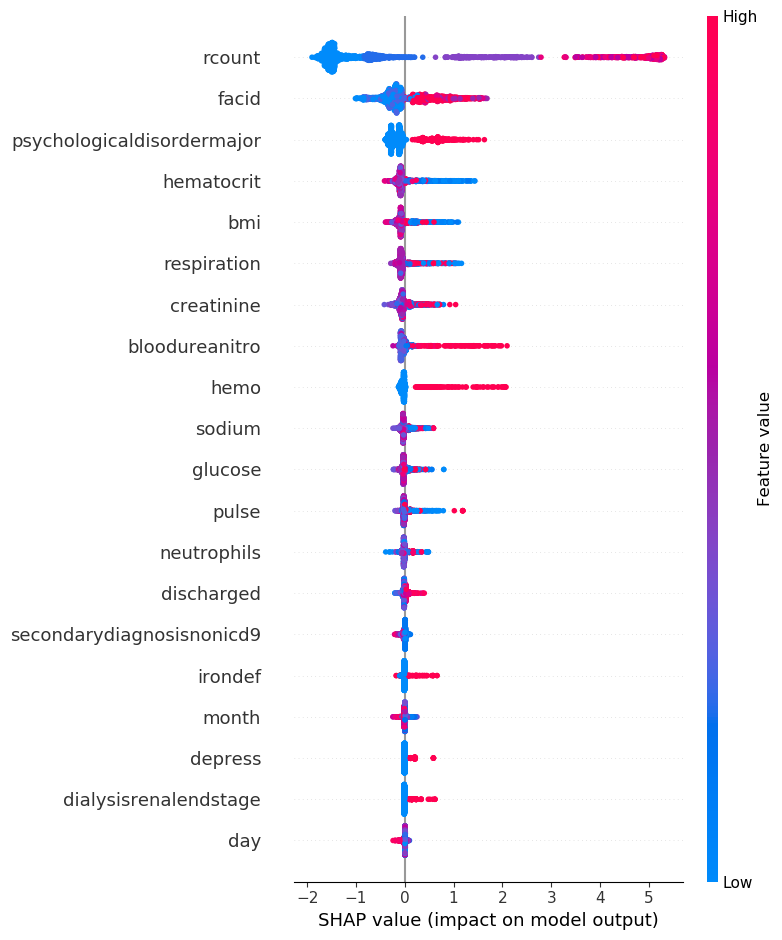

In [22]:
#summarry plot to explain names of features which is contributing most for the algorithm to make correct prediction
shap.summary_plot(shap_values, X_train, feature_names=cols)

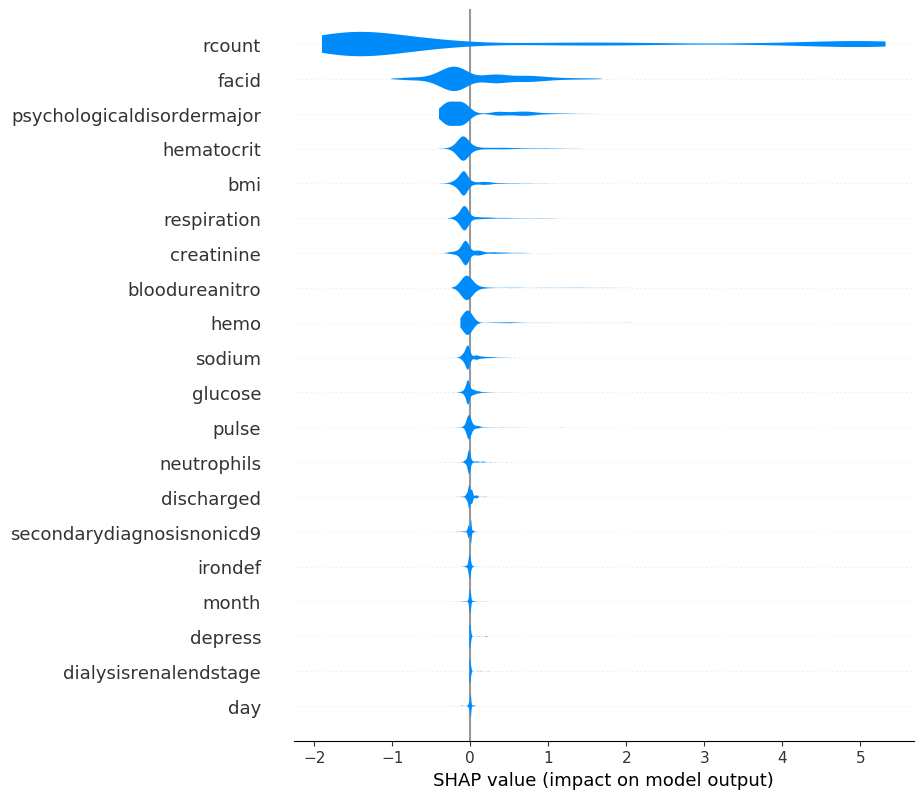

In [23]:
#violin plot to explain names of features which is contributing most for the algorithm to make correct prediction
shap.plots.violin(shap_values, feature_names=cols)

In [24]:
#reading test data value and then apply processing and extension catboot to predict ICU stay
testData = pd.read_csv("Dataset/testData.csv")
data = testData.values
testData['vdate'] = pd.to_datetime(testData['vdate'])#convert date into numeric date format
testData['year'] = testData['vdate'].dt.year
testData['month'] = testData['vdate'].dt.month
testData['day'] = testData['vdate'].dt.day
for i in range(len(label_encoder)):#convert string data to numeric values
    le = label_encoder[i]
    testData[le[0]] = pd.Series(le[1].transform(testData[le[0]].astype(str)))#encode all str columns to numeric
testData.drop(['eid', 'vdate'], axis = 1,inplace=True)#drop ir-relevant columns
#handling missing values using imputation
testData = testData.fillna(dataset.mean())
testData = testData.values
testData = scaler.transform(testData)#normalize test data
predict = extension_model.predict(testData)#perform prediction on test data using extension model
for i in range(len(predict)):
    print("Test Data = "+str(data[i])+" Predicted ICU Stay ====> "+labels[predict[i]])
    print()

Test Data = [14506 '8/13/2012' 3 'F' 0 0 0 1 0 0 0 1 0 0 0 12.0 5.8 138.826729
 157.1696287 16.0 1.304362491 30.633325 71 8.1 1 '8/19/2012' 'E'] Predicted ICU Stay ====> Long Stay

Test Data = [14507 '3/15/2012' 4 'M' 0 0 1 0 0 0 0 0 0 0 1 13.0 7.0 141.9320738
 108.7329284 27.0 1.126119855 29.31267226 69 7.9 1 '3/23/2012' 'C'] Predicted ICU Stay ====> Long Stay

Test Data = [14508 '7/8/2012' 1 'F' 0 0 0 0 0 1 0 0 0 0 0 9.8 18.5 136.0386032
 166.0632669 12.0 1.097952816 29.51596856 98 6.5 10 '7/12/2012' 'A'] Predicted ICU Stay ====> Short Stay

Test Data = [14509 '6/12/2012' 4 'F' 0 0 0 0 0 0 0 0 0 0 1 11.1 21.3 134.3474078
 92.09739372 12.0 1.276090102 28.79736033 54 5.7 1 '6/24/2012' 'B'] Predicted ICU Stay ====> Long Stay

Test Data = [14510 '7/24/2012' 0 'M' 0 0 0 0 0 0 0 0 0 0 0 13.0 8.7 137.1925297
 188.4013462 17.0 0.830555059 32.56155403 79 6.7 1 '7/27/2012' 'A'] Predicted ICU Stay ====> Short Stay

Test Data = [14511 '12/2/2012' 0 'M' 0 0 0 0 0 1 1 0 0 0 0 11.9 9.4 136.7409452


In [25]:
#=================flask code starts here
from flask import Flask, render_template, request, redirect, url_for, session,send_from_directory

In [26]:
app = Flask(__name__)
app.secret_key = 'welcome'

In [27]:
@app.route('/Predict', methods=['GET', 'POST'])
def predictView():
    return render_template('Predict.html', msg='')

@app.route('/index', methods=['GET', 'POST'])
def index():
    return render_template('index.html', msg='')

@app.route('/AdminLogin', methods=['GET', 'POST'])
def AdminLogin():
    return render_template('AdminLogin.html', msg='')

@app.route('/AdminLoginAction', methods=['GET', 'POST'])
def AdminLoginAction():
    if request.method == 'POST' and 't1' in request.form and 't2' in request.form:
        user = request.form['t1']
        password = request.form['t2']
        if user == "admin" and password == "admin":
            return render_template('AdminScreen.html', msg="Welcome "+user)
        else:
            return render_template('AdminLogin.html', msg="Invalid login details")

@app.route('/Logout')
def Logout():
    return render_template('index.html', msg='')

@app.route('/PredictAction', methods=['GET', 'POST'])
def PredictAction():
    if request.method == 'POST':
        testData = pd.read_csv("Dataset/testData.csv")
        data = testData.values
        testData['vdate'] = pd.to_datetime(testData['vdate'])#convert date into numeric date format
        testData['year'] = testData['vdate'].dt.year
        testData['month'] = testData['vdate'].dt.month
        testData['day'] = testData['vdate'].dt.day
        for i in range(len(label_encoder)):#convert string data to numeric values
            le = label_encoder[i]
            testData[le[0]] = pd.Series(le[1].transform(testData[le[0]].astype(str)))#encode all str columns to numeric
        testData.drop(['eid', 'vdate'], axis = 1,inplace=True)#drop ir-relevant columns
        #handling missing values using imputation
        testData = testData.fillna(dataset.mean())
        testData = testData.values
        testData = scaler.transform(testData)#normalize test data
        predict = extension_model.predict(testData)#perform prediction on test data using extension model
        output = ""
        for i in range(len(predict)):
            output += "Test Data = "+str(data[i])+" Predicted ICU Stay ====> "+labels[predict[i]]+"<br/><br/>" 
        return render_template('AdminScreen.html', msg=output)